# Notebook 2: Limpeza e Transformacao dos Dados

Este notebook primeiro visualiza os principais problemas dos datasets e, em seguida, aplica etapas de limpeza e padronizacao antes da exportacao dos dados tratados.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")


## 2.1 Carregamento dos dados


In [2]:
base = Path("../data/raw")

customer_df = pd.read_excel(base / "customer_data.xlsx")
sales_df = pd.read_excel(base / "sales_data.xlsx")
shopping_df = pd.read_excel(base / "shopping_mall_data.xlsx")

display(customer_df.head())
display(sales_df.head())
display(shopping_df.head())


,customer_id,gender,age,payment_method
0,C241288,Female,28.0,Credit Card
1,C111565,Male,21.0,Debit Card
2,C266599,Male,20.0,Cash
3,C988172,Female,66.0,Credit Card
4,C189076,Female,53.0,Cash


,invoice_no,customer_id,category,quantity,invoice date,price,shopping_mall
0,I138884,C241288,Clothing,5,05/08/2022,1500.40,South Coast Plaza
1,I317333,C111565,Shoes,3,12/12/2021,1800.51,Beverly Center
2,I127801,C266599,Clothing,1,09/11/2021,300.08,Westfield Century City
3,I173702,C988172,Shoes,5,05/16/2021,3000.85,Stanford Shopping Center
4,I337046,C189076,Books,4,10/24/2021,60.60,South Coast Plaza


,shopping_mall,construction_year,area (sqm),location,store_count
0,South Coast Plaza,1967,250000,Costa Mesa,270
1,Westfield Valley Fair,1986,220000,Santa Clara,230
2,The Grove,2002,56000,Los Angeles,140
3,Westfield Century City,1964,133000,Los Angeles,200
4,Beverly Center,1982,111000,Los Angeles,160


## 2.2 Diagnostico inicial


In [3]:
def resumo_limpeza(df, nome):
    print(f"=== {nome} ===")
    print("shape:", df.shape)
    print("duplicatas:", df.duplicated().sum())
    print("nulos por coluna:")
    print(df.isna().sum())
    print("dtypes:")
    print(df.dtypes)
    print()

resumo_limpeza(customer_df, "customer_df")
resumo_limpeza(sales_df, "sales_df")
resumo_limpeza(shopping_df, "shopping_df")


=== customer_df ===
shape: (99457, 4)
duplicatas: 0
nulos por coluna:
customer_id         0
gender              0
age               119
payment_method      0
dtype: int64
dtypes:
customer_id        object
gender             object
age               float64
payment_method     object
dtype: object

=== sales_df ===
shape: (99457, 7)
duplicatas: 0
nulos por coluna:
invoice_no       0
customer_id      0
category         0
quantity         0
invoice date     0
price            0
shopping_mall    0
dtype: int64
dtypes:
invoice_no        object
customer_id       object
category          object
quantity           int64
invoice date      object
price            float64
shopping_mall     object
dtype: object

=== shopping_df ===
shape: (10, 5)
duplicatas: 0
nulos por coluna:
shopping_mall        0
construction_year    0
area (sqm)           0
location             0
store_count          0
dtype: int64
dtypes:
shopping_mall        object
construction_year     int64
area (sqm)            int64
loca

## 2.3 Visualizacao dos problemas antes do tratamento

As celulas abaixo ajudam a enxergar nulos, possiveis discrepancias, duplicatas e inconsistencias de formato antes da limpeza propriamente dita.


### 2.3.1 Valores ausentes


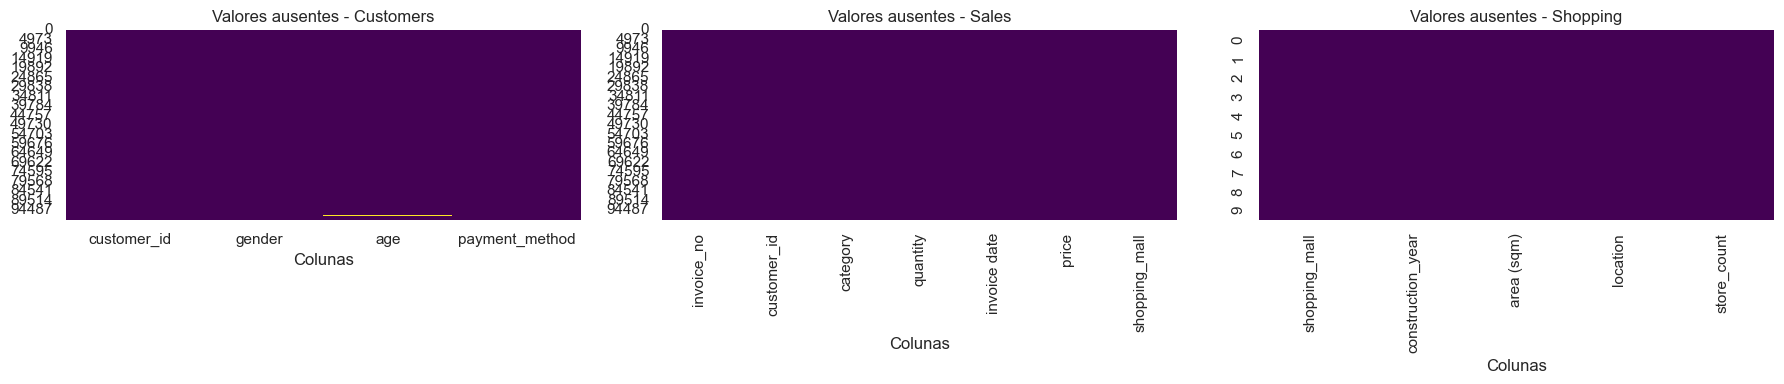

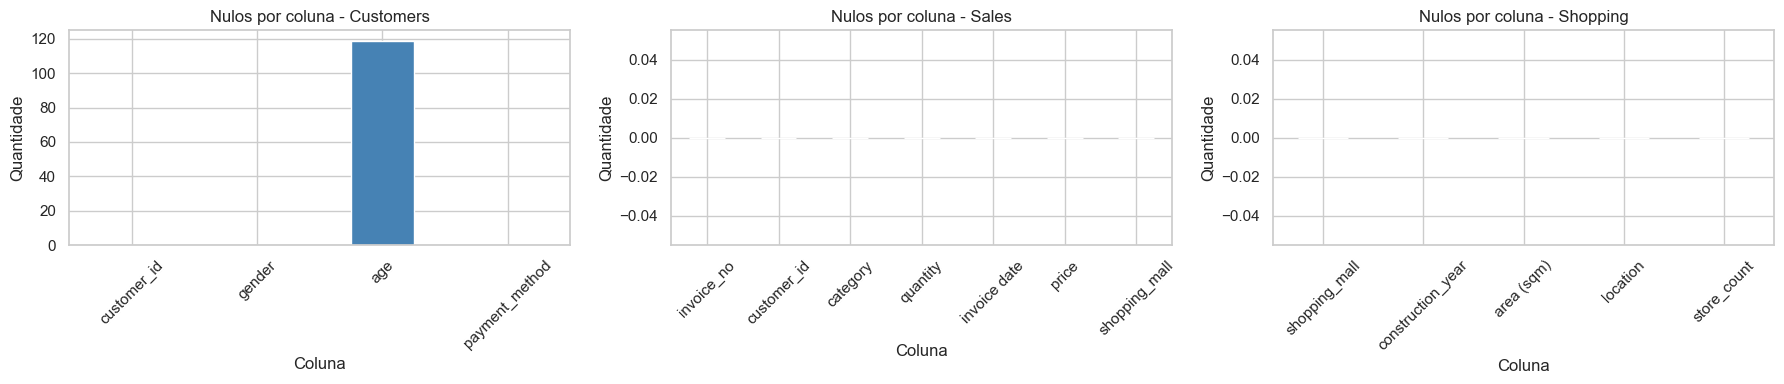

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (nome, df) in zip(axes, [("Customers", customer_df), ("Sales", sales_df), ("Shopping", shopping_df)]):
    sns.heatmap(df.isnull(), cbar=False, cmap="viridis", ax=ax)
    ax.set_title(f"Valores ausentes - {nome}")
    ax.set_xlabel("Colunas")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (nome, df) in zip(axes, [("Customers", customer_df), ("Sales", sales_df), ("Shopping", shopping_df)]):
    df.isnull().sum().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Nulos por coluna - {nome}")
    ax.set_xlabel("Coluna")
    ax.set_ylabel("Quantidade")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### 2.3.2 Valores discrepantes


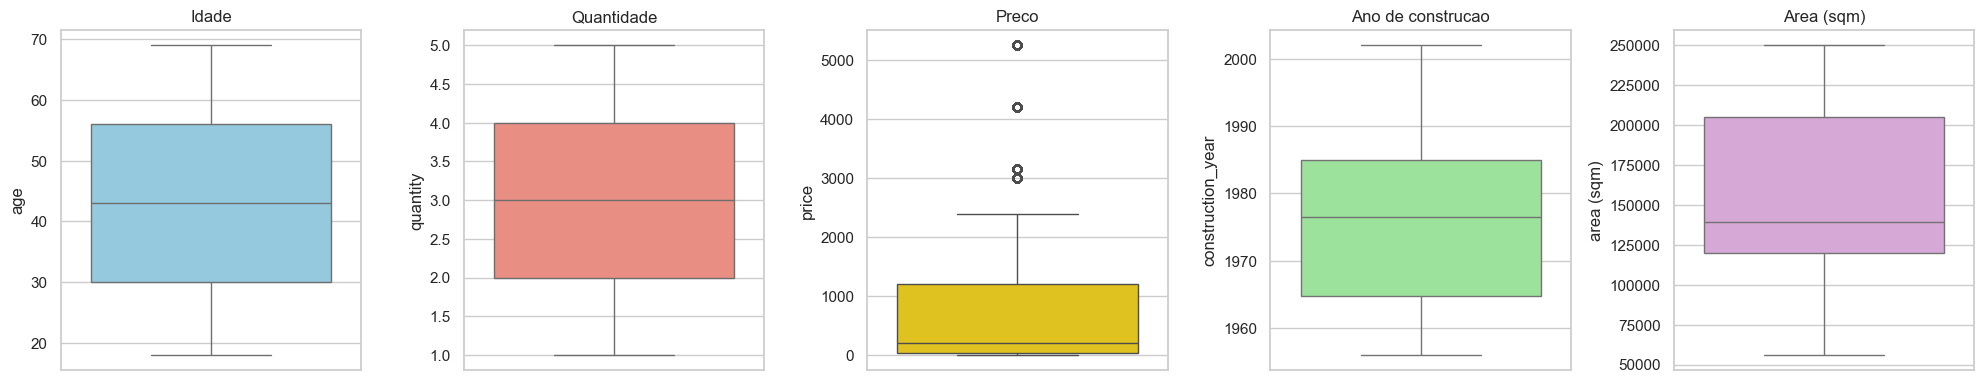

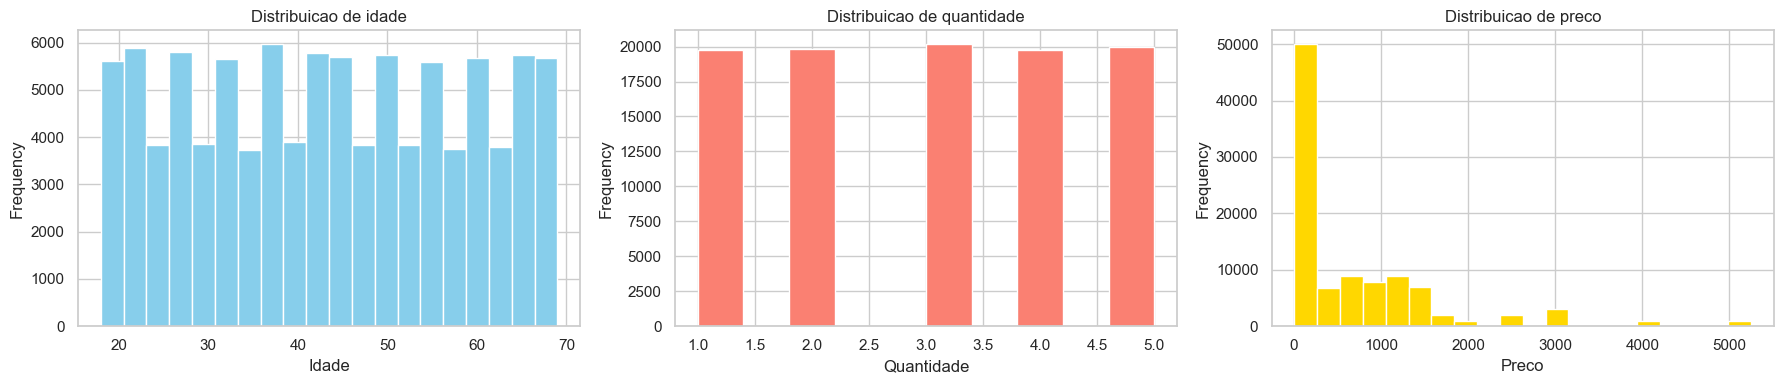

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

sns.boxplot(y=customer_df["age"], ax=axes[0], color="skyblue")
axes[0].set_title("Idade")

sns.boxplot(y=sales_df["quantity"], ax=axes[1], color="salmon")
axes[1].set_title("Quantidade")

sns.boxplot(y=sales_df["price"], ax=axes[2], color="gold")
axes[2].set_title("Preco")

sns.boxplot(y=shopping_df["construction_year"], ax=axes[3], color="lightgreen")
axes[3].set_title("Ano de construcao")

sns.boxplot(y=shopping_df["area (sqm)"], ax=axes[4], color="plum")
axes[4].set_title("Area (sqm)")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

customer_df["age"].dropna().plot(kind="hist", bins=20, ax=axes[0], color="skyblue")
axes[0].set_title("Distribuicao de idade")
axes[0].set_xlabel("Idade")

sales_df["quantity"].plot(kind="hist", bins=10, ax=axes[1], color="salmon")
axes[1].set_title("Distribuicao de quantidade")
axes[1].set_xlabel("Quantidade")

sales_df["price"].plot(kind="hist", bins=20, ax=axes[2], color="gold")
axes[2].set_title("Distribuicao de preco")
axes[2].set_xlabel("Preco")

plt.tight_layout()
plt.show()


### 2.3.3 Duplicatas


,dataset,duplicatas
0,customer_df,0
1,sales_df,0
2,shopping_df,0


C:\Users\Bruno Rocha\AppData\Local\Temp\ipykernel_16248\2876579930.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=duplicatas_df, x="dataset", y="duplicatas", palette="Blues_d")


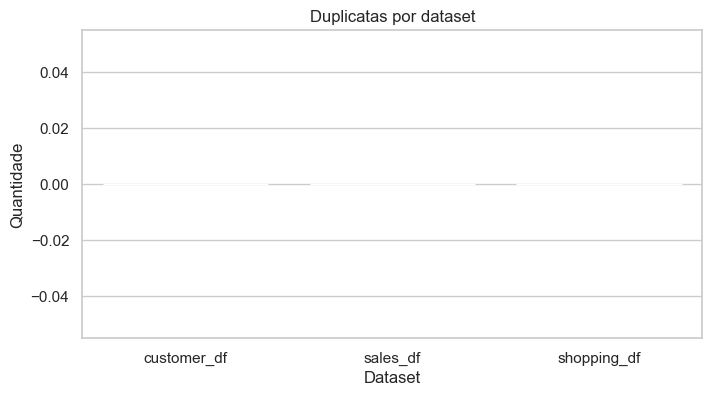

In [6]:
duplicatas_df = pd.DataFrame({
    "dataset": ["customer_df", "sales_df", "shopping_df"],
    "duplicatas": [
        customer_df.duplicated().sum(),
        sales_df.duplicated().sum(),
        shopping_df.duplicated().sum()
    ]
})

display(duplicatas_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=duplicatas_df, x="dataset", y="duplicatas", palette="Blues_d")
plt.title("Duplicatas por dataset")
plt.xlabel("Dataset")
plt.ylabel("Quantidade")
plt.show()


### 2.3.4 Inconsistencias e padronizacao necessaria


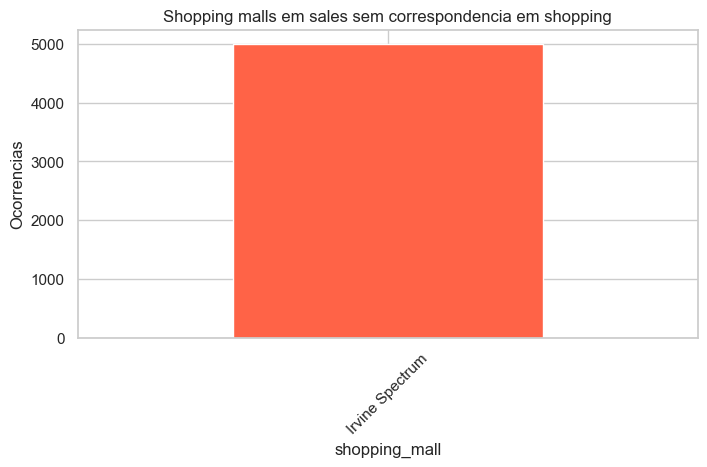

,gender_valores,payment_method_valores
0,Female,Cash
1,Male,Credit Card
2,NaN,Debit Card


,shopping_mall_sem_correspondencia,invoice_date_exemplo
0,Irvine Spectrum,05/08/2022
1,NaN,12/12/2021
2,NaN,09/11/2021
3,NaN,05/16/2021
4,NaN,10/24/2021


In [7]:
malls_sem_correspondencia = (
    sales_df.loc[~sales_df["shopping_mall"].isin(shopping_df["shopping_mall"]), "shopping_mall"]
    .value_counts()
)

if not malls_sem_correspondencia.empty:
    plt.figure(figsize=(8, 4))
    malls_sem_correspondencia.plot(kind="bar", color="tomato")
    plt.title("Shopping malls em sales sem correspondencia em shopping")
    plt.xlabel("shopping_mall")
    plt.ylabel("Ocorrencias")
    plt.xticks(rotation=45)
    plt.show()

display(pd.DataFrame({
    "gender_valores": pd.Series(sorted(customer_df["gender"].dropna().unique())),
    "payment_method_valores": pd.Series(sorted(customer_df["payment_method"].dropna().unique()))
}))

display(pd.DataFrame({
    "shopping_mall_sem_correspondencia": pd.Series(sorted(malls_sem_correspondencia.index.tolist())),
    "invoice_date_exemplo": pd.Series(sales_df["invoice date"].astype(str).head(5).tolist())
}))


### 2.3.5 Indicadores de transformacao


,variavel,valor_maximo
0,age,69.0
1,quantity,5.0
2,price,5250.0
3,construction_year,2002.0
4,area_sqm,250000.0
5,store_count,270.0


,variavel,n_categorias
0,gender,2
1,payment_method,3
2,category,8
3,location,8


C:\Users\Bruno Rocha\AppData\Local\Temp\ipykernel_16248\2021497581.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=escalas_numericas, x="variavel", y="valor_maximo", ax=axes[0], palette="crest")
C:\Users\Bruno Rocha\AppData\Local\Temp\ipykernel_16248\2021497581.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=categorias_df, x="variavel", y="n_categorias", ax=axes[1], palette="magma")


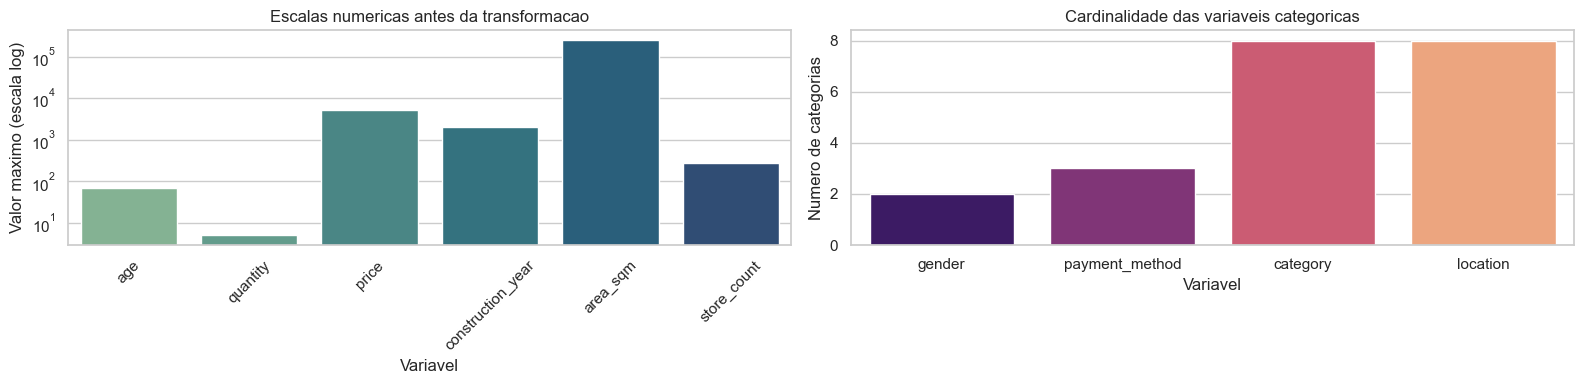

In [8]:
escalas_numericas = pd.DataFrame({
    "variavel": ["age", "quantity", "price", "construction_year", "area_sqm", "store_count"],
    "valor_maximo": [
        customer_df["age"].max(),
        sales_df["quantity"].max(),
        sales_df["price"].max(),
        shopping_df["construction_year"].max(),
        shopping_df["area (sqm)"].max(),
        shopping_df["store_count"].max()
    ]
})

categorias_df = pd.DataFrame({
    "variavel": ["gender", "payment_method", "category", "location"],
    "n_categorias": [
        customer_df["gender"].nunique(),
        customer_df["payment_method"].nunique(),
        sales_df["category"].nunique(),
        shopping_df["location"].nunique()
    ]
})

display(escalas_numericas)
display(categorias_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.barplot(data=escalas_numericas, x="variavel", y="valor_maximo", ax=axes[0], palette="crest")
axes[0].set_yscale("log")
axes[0].set_title("Escalas numericas antes da transformacao")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Valor maximo (escala log)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=categorias_df, x="variavel", y="n_categorias", ax=axes[1], palette="magma")
axes[1].set_title("Cardinalidade das variaveis categoricas")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de categorias")

plt.tight_layout()
plt.show()


## 2.4 Remocao de duplicatas


In [9]:
customer_clean = customer_df.drop_duplicates().copy()
sales_clean = sales_df.drop_duplicates().copy()
shopping_clean = shopping_df.drop_duplicates().copy()

print("customer removidas:", len(customer_df) - len(customer_clean))
print("sales removidas:", len(sales_df) - len(sales_clean))
print("shopping removidas:", len(shopping_df) - len(shopping_clean))


customer removidas: 0
sales removidas: 0
shopping removidas: 0


## 2.5 Padronizacao de formatos


In [10]:
sales_clean = sales_clean.rename(columns={"invoice date": "invoice_date"})
shopping_clean = shopping_clean.rename(columns={"area (sqm)": "area_sqm"})

def normalizar_texto(serie, modo="title"):
    serie = serie.astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
    if modo == "upper":
        return serie.str.upper()
    if modo == "lower":
        return serie.str.lower()
    return serie.str.title()

customer_clean["customer_id"] = normalizar_texto(customer_clean["customer_id"], modo="upper")
customer_clean["gender"] = normalizar_texto(customer_clean["gender"])
customer_clean["payment_method"] = normalizar_texto(customer_clean["payment_method"])

sales_clean["invoice_no"] = normalizar_texto(sales_clean["invoice_no"], modo="upper")
sales_clean["customer_id"] = normalizar_texto(sales_clean["customer_id"], modo="upper")
sales_clean["category"] = normalizar_texto(sales_clean["category"])
sales_clean["shopping_mall"] = normalizar_texto(sales_clean["shopping_mall"])

shopping_clean["shopping_mall"] = normalizar_texto(shopping_clean["shopping_mall"])
shopping_clean["location"] = normalizar_texto(shopping_clean["location"])

correcoes_shopping = {"Irvine Spectrum": "Irvine Spectrum Center"}
sales_clean["shopping_mall"] = sales_clean["shopping_mall"].replace(correcoes_shopping)

customer_clean["age"] = pd.to_numeric(customer_clean["age"], errors="coerce")
sales_clean["quantity"] = pd.to_numeric(sales_clean["quantity"], errors="coerce")
sales_clean["price"] = pd.to_numeric(sales_clean["price"], errors="coerce")
sales_clean["invoice_date"] = pd.to_datetime(sales_clean["invoice_date"], format="%m/%d/%Y", errors="coerce")
shopping_clean["construction_year"] = pd.to_numeric(shopping_clean["construction_year"], errors="coerce")
shopping_clean["area_sqm"] = pd.to_numeric(shopping_clean["area_sqm"], errors="coerce")
shopping_clean["store_count"] = pd.to_numeric(shopping_clean["store_count"], errors="coerce")

print(customer_clean.dtypes)
print()
print(sales_clean.dtypes)
print()
print(shopping_clean.dtypes)


customer_id       string[python]
gender            string[python]
age                      float64
payment_method    string[python]
dtype: object

invoice_no       string[python]
customer_id      string[python]
category         string[python]
quantity                  int64
invoice_date     datetime64[ns]
price                   float64
shopping_mall    string[python]
dtype: object

shopping_mall        string[python]
construction_year             int64
area_sqm                      int64
location             string[python]
store_count                   int64
dtype: object


## 2.6 Tratamento de valores discrepantes


In [11]:
ano_atual = pd.Timestamp.today().year

idade_invalida = ~customer_clean["age"].between(0, 100) & customer_clean["age"].notna()
quantidade_invalida = sales_clean["quantity"] <= 0
preco_invalido = sales_clean["price"] <= 0
ano_invalido = ~shopping_clean["construction_year"].between(1900, ano_atual)
area_invalida = shopping_clean["area_sqm"] <= 0
lojas_invalidas = shopping_clean["store_count"] <= 0

print("idades invalidas:", idade_invalida.sum())
print("quantidades invalidas:", quantidade_invalida.sum())
print("precos invalidos:", preco_invalido.sum())
print("anos invalidos:", ano_invalido.sum())
print("areas invalidas:", area_invalida.sum())
print("lojas invalidas:", lojas_invalidas.sum())

customer_clean.loc[idade_invalida, "age"] = pd.NA
sales_clean = sales_clean.loc[~(quantidade_invalida | preco_invalido)].copy()
shopping_clean = shopping_clean.loc[~(ano_invalido | area_invalida | lojas_invalidas)].copy()

print("\nShapes apos remover discrepantes:")
print("customer_clean:", customer_clean.shape)
print("sales_clean:", sales_clean.shape)
print("shopping_clean:", shopping_clean.shape)


idades invalidas: 0
quantidades invalidas: 0
precos invalidos: 0
anos invalidos: 0
areas invalidas: 0
lojas invalidas: 0

Shapes apos remover discrepantes:
customer_clean: (99457, 4)
sales_clean: (99457, 7)
shopping_clean: (10, 5)


## 2.7 Tratamento de valores ausentes e inconsistencias


In [12]:
idade_mediana = customer_clean["age"].median()
customer_clean["age"] = customer_clean["age"].fillna(idade_mediana)

generos_validos = {"Female", "Male"}
pagamentos_validos = {"Cash", "Credit Card", "Debit Card"}

print("generos fora do padrao:", customer_clean.loc[~customer_clean["gender"].isin(generos_validos), "gender"].dropna().unique())
print("pagamentos fora do padrao:", customer_clean.loc[~customer_clean["payment_method"].isin(pagamentos_validos), "payment_method"].dropna().unique())

sales_clean = sales_clean.dropna(subset=["invoice_date", "quantity", "price"])
shopping_clean = shopping_clean.dropna(subset=["construction_year", "area_sqm", "store_count"])

customer_clean["age"] = customer_clean["age"].round().astype("int64")
sales_clean["quantity"] = sales_clean["quantity"].astype("int64")
shopping_clean["construction_year"] = shopping_clean["construction_year"].astype("int64")
shopping_clean["area_sqm"] = shopping_clean["area_sqm"].astype("int64")
shopping_clean["store_count"] = shopping_clean["store_count"].astype("int64")

print("nulos apos tratamento:\n")
print("customer_clean")
print(customer_clean.isna().sum())
print()
print("sales_clean")
print(sales_clean.isna().sum())
print()
print("shopping_clean")
print(shopping_clean.isna().sum())


generos fora do padrao: <StringArray>
[]
Length: 0, dtype: string
pagamentos fora do padrao: <StringArray>
[]
Length: 0, dtype: string
nulos apos tratamento:

customer_clean
customer_id       0
gender            0
age               0
payment_method    0
dtype: int64

sales_clean
invoice_no       0
customer_id      0
category         0
quantity         0
invoice_date     0
price            0
shopping_mall    0
dtype: int64

shopping_clean
shopping_mall        0
construction_year    0
area_sqm             0
location             0
store_count          0
dtype: int64


## 2.8 Validacao entre os datasets


In [13]:
customer_sem_venda = customer_clean.loc[~customer_clean["customer_id"].isin(sales_clean["customer_id"]), "customer_id"].nunique()
venda_sem_customer = sales_clean.loc[~sales_clean["customer_id"].isin(customer_clean["customer_id"]), "customer_id"].nunique()
venda_sem_shopping = sales_clean.loc[~sales_clean["shopping_mall"].isin(shopping_clean["shopping_mall"]), "shopping_mall"].nunique()

print("customers sem vendas:", customer_sem_venda)
print("customer_id em sales sem correspondencia:", venda_sem_customer)
print("shopping_mall em sales sem correspondencia:", venda_sem_shopping)


customers sem vendas: 0
customer_id em sales sem correspondencia: 0
shopping_mall em sales sem correspondencia: 0


## 2.9 Dataset final tratado


In [14]:
resumo_limpeza(customer_clean, "customer_clean")
resumo_limpeza(sales_clean, "sales_clean")
resumo_limpeza(shopping_clean, "shopping_clean")

display(customer_clean.head())
display(sales_clean.head())
display(shopping_clean.head())


=== customer_clean ===
shape: (99457, 4)
duplicatas: 0
nulos por coluna:
customer_id       0
gender            0
age               0
payment_method    0
dtype: int64
dtypes:
customer_id       string[python]
gender            string[python]
age                        int64
payment_method    string[python]
dtype: object

=== sales_clean ===
shape: (99457, 7)
duplicatas: 0
nulos por coluna:
invoice_no       0
customer_id      0
category         0
quantity         0
invoice_date     0
price            0
shopping_mall    0
dtype: int64
dtypes:
invoice_no       string[python]
customer_id      string[python]
category         string[python]
quantity                  int64
invoice_date     datetime64[ns]
price                   float64
shopping_mall    string[python]
dtype: object

=== shopping_clean ===
shape: (10, 5)
duplicatas: 0
nulos por coluna:
shopping_mall        0
construction_year    0
area_sqm             0
location             0
store_count          0
dtype: int64
dtypes:
shopping_m

,customer_id,gender,age,payment_method
0,C241288,Female,28,Credit Card
1,C111565,Male,21,Debit Card
2,C266599,Male,20,Cash
3,C988172,Female,66,Credit Card
4,C189076,Female,53,Cash


,invoice_no,customer_id,category,quantity,invoice_date,price,shopping_mall
0,I138884,C241288,Clothing,5,2022-05-08,1500.40,South Coast Plaza
1,I317333,C111565,Shoes,3,2021-12-12,1800.51,Beverly Center
2,I127801,C266599,Clothing,1,2021-09-11,300.08,Westfield Century City
3,I173702,C988172,Shoes,5,2021-05-16,3000.85,Stanford Shopping Center
4,I337046,C189076,Books,4,2021-10-24,60.60,South Coast Plaza


,shopping_mall,construction_year,area_sqm,location,store_count
0,South Coast Plaza,1967,250000,Costa Mesa,270
1,Westfield Valley Fair,1986,220000,Santa Clara,230
2,The Grove,2002,56000,Los Angeles,140
3,Westfield Century City,1964,133000,Los Angeles,200
4,Beverly Center,1982,111000,Los Angeles,160


## 2.10 Transformacoes dos dados


In [15]:
customer_transf = customer_clean.copy()
sales_transf = sales_clean.copy()
shopping_transf = shopping_clean.copy()


### 2.10.1 Escalonamento e normalizacao


In [16]:
def minmax_scale(serie):
    amplitude = serie.max() - serie.min()
    if amplitude == 0:
        return pd.Series(0, index=serie.index, dtype="float64")
    return (serie - serie.min()) / amplitude

def zscore_scale(serie):
    desvio = serie.std(ddof=0)
    if desvio == 0:
        return pd.Series(0, index=serie.index, dtype="float64")
    return (serie - serie.mean()) / desvio

customer_transf["age_minmax"] = minmax_scale(customer_transf["age"])
customer_transf["age_zscore"] = zscore_scale(customer_transf["age"])

sales_transf["quantity_minmax"] = minmax_scale(sales_transf["quantity"])
sales_transf["quantity_zscore"] = zscore_scale(sales_transf["quantity"])
sales_transf["price_minmax"] = minmax_scale(sales_transf["price"])
sales_transf["price_zscore"] = zscore_scale(sales_transf["price"])

shopping_transf["area_sqm_minmax"] = minmax_scale(shopping_transf["area_sqm"])
shopping_transf["area_sqm_zscore"] = zscore_scale(shopping_transf["area_sqm"])
shopping_transf["store_count_minmax"] = minmax_scale(shopping_transf["store_count"])
shopping_transf["store_count_zscore"] = zscore_scale(shopping_transf["store_count"])

display(customer_transf[["age", "age_minmax", "age_zscore"]].head())
display(sales_transf[["quantity", "quantity_minmax", "quantity_zscore", "price", "price_minmax", "price_zscore"]].head())
display(shopping_transf[["area_sqm", "area_sqm_minmax", "area_sqm_zscore", "store_count", "store_count_minmax", "store_count_zscore"]].head())


,age,age_minmax,age_zscore
0,28,0.196078,-1.029705
1,21,0.058824,-1.496983
2,20,0.039216,-1.563737
3,66,0.941176,1.506950
4,53,0.686275,0.639147


,quantity,quantity_minmax,quantity_zscore,price,price_minmax,price_zscore
0,5,1.00,1.412984,1500.40,0.285078,0.861837
1,3,0.50,-0.002426,1800.51,0.342299,1.180703
2,1,0.00,-1.417837,300.08,0.056218,-0.413498
3,5,1.00,1.412984,3000.85,0.571163,2.456060
4,4,0.75,0.705279,60.60,0.010557,-0.667945


,area_sqm,area_sqm_minmax,area_sqm_zscore,store_count,store_count_minmax,store_count_zscore
0,250000,1.000000,1.633012,270,1.000000,1.956135
1,220000,0.845361,1.118408,230,0.714286,1.024642
2,56000,0.000000,-1.694765,140,0.071429,-1.071217
3,133000,0.396907,-0.373946,200,0.500000,0.326023
4,111000,0.283505,-0.751323,160,0.214286,-0.605470


### 2.10.2 Codificacao de categorias


In [17]:
customer_dummies = pd.get_dummies(
    customer_transf[["gender", "payment_method"]],
    columns=["gender", "payment_method"],
    dtype="int64"
)

sales_dummies = pd.get_dummies(
    sales_transf[["category"]],
    columns=["category"],
    dtype="int64"
)

shopping_dummies = pd.get_dummies(
    shopping_transf[["location"]],
    columns=["location"],
    dtype="int64"
)

customer_transf = pd.concat([customer_transf, customer_dummies], axis=1)
sales_transf = pd.concat([sales_transf, sales_dummies], axis=1)
shopping_transf = pd.concat([shopping_transf, shopping_dummies], axis=1)

display(customer_transf.head())
display(sales_transf.head())
display(shopping_transf.head())


,customer_id,gender,age,payment_method,age_minmax,age_zscore,gender_Female,gender_Male,payment_method_Cash,payment_method_Credit Card,payment_method_Debit Card
0,C241288,Female,28,Credit Card,0.196078,-1.029705,1,0,0,1,0
1,C111565,Male,21,Debit Card,0.058824,-1.496983,0,1,0,0,1
2,C266599,Male,20,Cash,0.039216,-1.563737,0,1,1,0,0
3,C988172,Female,66,Credit Card,0.941176,1.506950,1,0,0,1,0
4,C189076,Female,53,Cash,0.686275,0.639147,1,0,1,0,0


,invoice_no,customer_id,category,quantity,invoice_date,price,shopping_mall,quantity_minmax,quantity_zscore,price_minmax,price_zscore,category_Books,category_Clothing,category_Cosmetics,category_Food & Beverage,category_Shoes,category_Souvenir,category_Technology,category_Toys
0,I138884,C241288,Clothing,5,2022-05-08,1500.40,South Coast Plaza,1.00,1.412984,0.285078,0.861837,0,1,0,0,0,0,0,0
1,I317333,C111565,Shoes,3,2021-12-12,1800.51,Beverly Center,0.50,-0.002426,0.342299,1.180703,0,0,0,0,1,0,0,0
2,I127801,C266599,Clothing,1,2021-09-11,300.08,Westfield Century City,0.00,-1.417837,0.056218,-0.413498,0,1,0,0,0,0,0,0
3,I173702,C988172,Shoes,5,2021-05-16,3000.85,Stanford Shopping Center,1.00,1.412984,0.571163,2.456060,0,0,0,0,1,0,0,0
4,I337046,C189076,Books,4,2021-10-24,60.60,South Coast Plaza,0.75,0.705279,0.010557,-0.667945,1,0,0,0,0,0,0,0


,shopping_mall,construction_year,area_sqm,location,store_count,area_sqm_minmax,area_sqm_zscore,store_count_minmax,store_count_zscore,location_Costa Mesa,location_Glendale,location_Irvine,location_Los Angeles,location_Palo Alto,location_San Diego,location_Santa Clara,location_Torrance
0,South Coast Plaza,1967,250000,Costa Mesa,270,1.000000,1.633012,1.000000,1.956135,1,0,0,0,0,0,0,0
1,Westfield Valley Fair,1986,220000,Santa Clara,230,0.845361,1.118408,0.714286,1.024642,0,0,0,0,0,0,1,0
2,The Grove,2002,56000,Los Angeles,140,0.000000,-1.694765,0.071429,-1.071217,0,0,0,1,0,0,0,0
3,Westfield Century City,1964,133000,Los Angeles,200,0.396907,-0.373946,0.500000,0.326023,0,0,0,1,0,0,0,0
4,Beverly Center,1982,111000,Los Angeles,160,0.283505,-0.751323,0.214286,-0.605470,0,0,0,1,0,0,0,0


### 2.10.3 Geracao de novas variaveis


In [18]:
sales_transf["valor_total_compra"] = sales_transf["price"]
sales_transf["preco_unitario_estimado"] = sales_transf["price"] / sales_transf["quantity"]
sales_transf["ano_compra"] = sales_transf["invoice_date"].dt.year
sales_transf["mes_compra"] = sales_transf["invoice_date"].dt.month
sales_transf["trimestre_compra"] = sales_transf["invoice_date"].dt.quarter

vendas_por_shopping = (
    sales_transf.groupby("shopping_mall", as_index=False)
    .agg(
        vendas_por_shopping=("valor_total_compra", "sum"),
        quantidade_total_itens=("quantity", "sum"),
        ticket_medio=("valor_total_compra", "mean"),
        total_transacoes=("invoice_no", "count")
    )
)

shopping_transf = shopping_transf.merge(vendas_por_shopping, on="shopping_mall", how="left")

display(sales_transf[["invoice_no", "quantity", "price", "valor_total_compra", "preco_unitario_estimado", "ano_compra", "mes_compra", "trimestre_compra"]].head())
display(vendas_por_shopping.sort_values("vendas_por_shopping", ascending=False).head(10))
display(shopping_transf.head())


,invoice_no,quantity,price,valor_total_compra,preco_unitario_estimado,ano_compra,mes_compra,trimestre_compra
0,I138884,5,1500.40,1500.40,300.08,2022,5,2
1,I317333,3,1800.51,1800.51,600.17,2021,12,4
2,I127801,1,300.08,300.08,300.08,2021,9,3
3,I173702,5,3000.85,3000.85,600.17,2021,5,2
4,I337046,4,60.60,60.60,15.15,2021,10,4


,shopping_mall,vendas_por_shopping,quantidade_total_itens,ticket_medio,total_transacoes
1,Del Amo Fashion Center,13851737.62,60114,694.566395,19943
5,South Coast Plaza,13710755.24,59457,691.658944,19823
8,Westfield Century City,10249980.07,44894,682.831262,15011
6,Stanford Shopping Center,6937992.99,30530,682.806120,10161
9,Westfield Valley Fair,6717077.54,29465,686.747525,9781
2,Fashion Valley,3509649.02,15234,691.556457,5075
4,Irvine Spectrum Center,3433671.84,14949,687.972719,4991
3,Glendale Galleria,3414019.46,14716,694.753655,4914
7,The Grove,3390408.31,14501,704.720081,4811
0,Beverly Center,3336073.82,14852,674.363012,4947


,shopping_mall,construction_year,area_sqm,location,store_count,area_sqm_minmax,area_sqm_zscore,store_count_minmax,store_count_zscore,location_Costa Mesa,...,location_Irvine,location_Los Angeles,location_Palo Alto,location_San Diego,location_Santa Clara,location_Torrance,vendas_por_shopping,quantidade_total_itens,ticket_medio,total_transacoes
0,South Coast Plaza,1967,250000,Costa Mesa,270,1.000000,1.633012,1.000000,1.956135,1,...,0,0,0,0,0,0,13710755.24,59457,691.658944,19823
1,Westfield Valley Fair,1986,220000,Santa Clara,230,0.845361,1.118408,0.714286,1.024642,0,...,0,0,0,0,1,0,6717077.54,29465,686.747525,9781
2,The Grove,2002,56000,Los Angeles,140,0.000000,-1.694765,0.071429,-1.071217,0,...,0,1,0,0,0,0,3390408.31,14501,704.720081,4811
3,Westfield Century City,1964,133000,Los Angeles,200,0.396907,-0.373946,0.500000,0.326023,0,...,0,1,0,0,0,0,10249980.07,44894,682.831262,15011
4,Beverly Center,1982,111000,Los Angeles,160,0.283505,-0.751323,0.214286,-0.605470,0,...,0,1,0,0,0,0,3336073.82,14852,674.363012,4947


## 2.11 Exportacao dos dados finais


In [19]:
saida = Path("../data/processed")
saida.mkdir(parents=True, exist_ok=True)

customer_transf.to_excel(saida / "customer_data_clean.xlsx", index=False)
sales_transf.to_excel(saida / "sales_data_clean.xlsx", index=False)
shopping_transf.to_excel(saida / "shopping_mall_data_clean.xlsx", index=False)

print("Arquivos salvos em:", saida.resolve())


Arquivos salvos em: C:\Users\Bruno Rocha\Documents\GitHub\data-science2026\data\processed
